# CSoT'26 — ML in Astronomy — Week 1 · Part 2: Data Pipeline (Starter)

**Goal:** Get the Galaxy Zoo 2 images flowing through a PyTorch data pipeline and *look at them*.

By the end you'll have an `ImageFolder` dataset, a `DataLoader` yielding `(32, 3, 64, 64)` batches, and a matplotlib grid of real galaxies.

**Before you begin:**
1. Finish **Part 1** (`week1_starter.ipynb`) first.
2. Switch this notebook to a **GPU runtime** (`Runtime → Change runtime type → GPU`). Not strictly required for data loading, but keeps you consistent.
3. Read [`08-data-pipelines.md`](../08-data-pipelines.md) — every TODO below maps to a section there.

Attempt every TODO before opening `week1_data_solution.ipynb`.

## Step 0 — Imports

In [1]:
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torchvision
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


## Step 1 — Get the dataset into Colab

Two options:

**Option A — Kaggle API (full dataset).** Upload your `kaggle.json` token, then:
```python
from google.colab import files
files.upload()  # choose kaggle.json
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!pip -q install kaggle
!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images
!unzip -q galaxy-zoo-2-images.zip -d galaxy_data
```

**Option B — Small subset for a fast first run.** If the full download is slow, build a tiny balanced subset (the solution notebook shows one way). For now, set `DATA_ROOT` to wherever your `train/<class>/...jpg` folders live.

Fill in the cell below to download/locate the data and set `DATA_ROOT`.

In [2]:
# TODO: download the dataset (Kaggle API) OR point DATA_ROOT at an existing folder.
#       DATA_ROOT must contain subfolders named by class, each full of images:
#         DATA_ROOT/elliptical/*.jpg, DATA_ROOT/spiral/*.jpg, ...
from google.colab import files
files.upload()  # choose kaggle.json
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!pip -q install kaggle
!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images
!unzip -q galaxy-zoo-2-images.zip -d galaxy_data
DATA_ROOT = "galaxy_data"

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.06G/3.06G [01:17<00:00, 42.6MB/s]



## Step 2 — Inspect the folder structure

Confirm the layout is `DATA_ROOT/<class_name>/<image>.jpg`. List the class subfolders and count a few.

In [3]:
#Adding and unzipping hart16
print("Upload gz2_hart16.csv.gz")
files.upload()
!gunzip -f gz2_hart16.csv.gz
# Create the target directory if it does not exist and move the file
!mkdir -p galaxy_data && mv gz2_hart16.csv galaxy_data

Upload gz2_hart16.csv.gz


Saving gz2_hart16.csv.gz to gz2_hart16.csv.gz


In [4]:
#following categorisation was written with help of AI by joining the csvs and categorising using obj ids
import os
import csv
def categorize_morphology(gz2_class_string):
    """Applies prefix rules to determine the high-level category."""

    class_str = gz2_class_string.strip().upper()

    if class_str.startswith('E'):
        return 'elliptical'
    elif class_str.startswith('SB'):
        return 'barred_spiral'
    elif class_str.startswith('S'):
        return 'spiral'
    elif class_str.startswith('A') or class_str.startswith('STAR'):
        return 'artifact'
    else:
        return 'irregular_or_other'

def process_galaxy_dataset(
    mapping_csv="galaxy_data/gz2_filename_mapping.csv",
    hart16_csv="galaxy_data/gz2_hart16.csv",
    source_image_dir="galaxy_data/images_gz2/images", # <-- Path updated here
    target_root_dir="galaxy_data/categorized_dataset"
):
    print("1. Building morphological lookup table...")
    class_lookup = {}

    with open(hart16_csv, mode='r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            class_lookup[row['dr7objid']] = row['gz2_class']

    print(f"Loaded {len(class_lookup):,} classifications into memory.")

    print("2. Constructing target directory structure...")
    categories = ['elliptical', 'barred_spiral', 'spiral', 'artifact']
    for category in categories:
        os.makedirs(os.path.join(target_root_dir, category), exist_ok=True)

    print("3. Matching IDs and generating symbolic links...")
    links_created = 0
    missing_files = 0
    match_failures = 0

    with open(mapping_csv, mode='r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            objid = row['objid']
            asset_id = row['asset_id']

            raw_class = class_lookup.get(objid)

            if not raw_class:
                match_failures += 1
                continue

            category = categorize_morphology(raw_class)

            image_filename = f"{asset_id}.jpg"
            source_path = os.path.join(source_image_dir, image_filename)
            target_path = os.path.join(target_root_dir, category, image_filename)

            if os.path.exists(source_path):
                if not os.path.exists(target_path):
                    relative_src = os.path.relpath(source_path, start=os.path.dirname(target_path))
                    os.symlink(relative_src, target_path)
                    links_created += 1
            else:
                missing_files += 1

    print("\n--- Execution Complete ---")
    print(f"Successfully generated links: {links_created:,}")
    if missing_files > 0:
        print(f"Skipped (Image missing on disk): {missing_files:,}")
    if match_failures > 0:
        print(f"Skipped (ID not found in Hart16 catalog): {match_failures:,}")

# Run the pipeline
process_galaxy_dataset()

1. Building morphological lookup table...
Loaded 239,695 classifications into memory.
2. Constructing target directory structure...
3. Matching IDs and generating symbolic links...

--- Execution Complete ---
Successfully generated links: 239,573
Skipped (Image missing on disk): 122
Skipped (ID not found in Hart16 catalog): 116,295


In [5]:
# TODO: list the subfolders of DATA_ROOT and print how many images are in each.
#       Hint: import os; os.listdir(DATA_ROOT)
import os
print(os.listdir("galaxy_data"))
DATA_ROOT="galaxy_data/categorized_dataset"
print("Class subfolders")
for c in os.listdir(os.path.join(DATA_ROOT)):
  if os.path.isdir(os.path.join(DATA_ROOT,c)):
    print(c+":",len(os.listdir(os.path.join(DATA_ROOT,c))))


['gz2_filename_mapping.csv', 'categorized_dataset', 'images_gz2', 'gz2_hart16.csv']
Class subfolders
barred_spiral: 73737
spiral: 67649
elliptical: 97643
artifact: 544


In [6]:
#To create Train and test
#following was written with help of AI due to the raw data being not usable by ImageFolder
import os
import random

def create_train_test_split(
    source_root="galaxy_data/categorized_dataset",
    train_ratio=0.80
):
    """
    Partitions categorized images into distinct train and test subdirectories
    located directly inside the source root directory.
    """
    # Establish target paths directly within the categorized_dataset folder
    train_dir = os.path.join(source_root, "train")
    test_dir = os.path.join(source_root, "test")

    random.seed(42)

    if not os.path.exists(source_root):
        print(f"Error: Source directory '{source_root}' not found.")
        return

    # Scan for categories, explicitly excluding 'train' and 'test' to avoid self-referencing loops
    categories = [
        d for d in os.listdir(source_root)
        if os.path.isdir(os.path.join(source_root, d)) and d not in ['train', 'test']
    ]

    print(f"Located {len(categories)} source categories for partitioning.\n")
    print(f"{'Category':<25} | {'Total Files':<12} | {'Train Count':<12} | {'Test Count':<12}")
    print("-" * 70)

    for category in categories:
        category_path = os.path.join(source_root, category)

        # Retrieve all images within the current category directory
        all_images = [f for f in os.listdir(category_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        total_count = len(all_images)

        if total_count == 0:
            continue

        # Shuffle file lists to randomize entry distribution
        random.shuffle(all_images)

        # Calculate distribution boundaries
        train_split_index = int(total_count * train_ratio)
        train_images = all_images[:train_split_index]
        test_images = all_images[train_split_index:]

        # Generate nested structure: categorized_dataset/train/category_name/
        os.makedirs(os.path.join(train_dir, category), exist_ok=True)
        os.makedirs(os.path.join(test_dir, category), exist_ok=True)

        # Create absolute symbolic links for the Training partition
        for img in train_images:
            src = os.path.abspath(os.path.join(category_path, img))
            dst = os.path.join(train_dir, category, img)
            if not os.path.exists(dst):
                os.symlink(src, dst)

        # Create absolute symbolic links for the Testing partition
        for img in test_images:
            src = os.path.abspath(os.path.join(category_path, img))
            dst = os.path.join(test_dir, category, img)
            if not os.path.exists(dst):
                os.symlink(src, dst)

        print(f"{category:<25} | {total_count:<12,} | {len(train_images):<12,} | {len(test_images):<12,}")

    print("\n==================================================")
    print("          DATASET PARTITIONING COMPLETE           ")
    print("==================================================")
    print(f"Train Subdirectory: {train_dir}")
    print(f"Test Subdirectory:  {test_dir}")

# Execute the updated partitioning function
create_train_test_split()

Located 4 source categories for partitioning.

Category                  | Total Files  | Train Count  | Test Count  
----------------------------------------------------------------------
barred_spiral             | 73,737       | 58,989       | 14,748      
spiral                    | 67,649       | 54,119       | 13,530      
elliptical                | 97,643       | 78,114       | 19,529      
artifact                  | 544          | 435          | 109         

          DATASET PARTITIONING COMPLETE           
Train Subdirectory: galaxy_data/categorized_dataset/train
Test Subdirectory:  galaxy_data/categorized_dataset/test


## Step 3 — Build the transforms pipeline

Compose: `Resize((64, 64))` → `ToTensor()` → `Normalize([0.5]*3, [0.5]*3)`.
See [`08-data-pipelines.md`](../08-data-pipelines.md) for why each step exists and why order matters.

In [7]:
# TODO: transform = transforms.Compose([... Resize, ToTensor, Normalize ...])
transform = transforms.Compose([
    transforms.Resize((64, 64)),          # make every image 64x64
    transforms.ToTensor(),                # PIL image -> tensor, and scale 0-255 -> 0.0-1.0
    transforms.Normalize(                 # standardise each channel
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5],
    ),
])
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(180),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

## Step 4 — Wrap it in an ImageFolder

Create `dataset = ImageFolder(root=DATA_ROOT, transform=transform)`. Print `len(dataset)`, `dataset.classes`, and `dataset.class_to_idx`.

*Remember:* classes are assigned **alphabetically**.

In [8]:
# TODO: create the ImageFolder and print len / classes / class_to_idx.
from torchvision.datasets import ImageFolder

train_ds = ImageFolder(root="galaxy_data/categorized_dataset/train", transform=train_transform)
test_ds  = ImageFolder(root="galaxy_data/categorized_dataset/test",  transform=transform)

print(len(train_ds))          # number of training images
print(train_ds.classes)       # ['elliptical', 'irregular', 'spiral'] (alphabetical)
print(train_ds.class_to_idx)  # {'elliptical': 0, 'irregular': 1, 'spiral': 2}



191657
['artifact', 'barred_spiral', 'elliptical', 'spiral']
{'artifact': 0, 'barred_spiral': 1, 'elliptical': 2, 'spiral': 3}


## Step 5 — Fetch a single sample

`image, label = dataset[0]`. Print `image.shape` (expect `torch.Size([3, 64, 64])`), `image.dtype`, and the integer `label`.

In [9]:
# TODO: fetch dataset[0] and print its shape, dtype, and label.

image, label = train_ds[0]
print(image.shape)
print(image.dtype)
print(label)

torch.Size([3, 64, 64])
torch.float32
0


## Step 6 — Build a DataLoader and peek at one batch

Create a `DataLoader` with `batch_size=32`, `shuffle=True`, `num_workers=2`. Grab one batch with `next(iter(loader))` and print `images.shape` (expect `(32, 3, 64, 64)`) and `labels.shape`.

In [10]:
# TODO: build the DataLoader, grab one batch, and print the batch shapes.
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=32,      # 32 images per batch
    shuffle=True,       # reshuffle every epoch (train only!)
    num_workers=2,      # parallel data-loading processes
    pin_memory=True,    # faster host->GPU transfer
)

test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
images, labels=next(iter(train_loader))
print(images.shape)   # torch.Size([32, 3, 64, 64])  -> (B, C, H, W)
print(labels.shape)   # torch.Size([32])

torch.Size([32, 3, 64, 64])
torch.Size([32])


## Step 7 — Plot a batch of galaxies

Plot ~16 images using `torchvision.utils.make_grid` + `plt.imshow`.

**Two gotchas (see the markdown):**
1. Undo the normalisation before plotting: `images * 0.5 + 0.5`.
2. matplotlib wants `(H, W, C)`, so `.permute(1, 2, 0)`.

Bonus: print the class names for the batch using `dataset.classes` and the `labels` tensor.

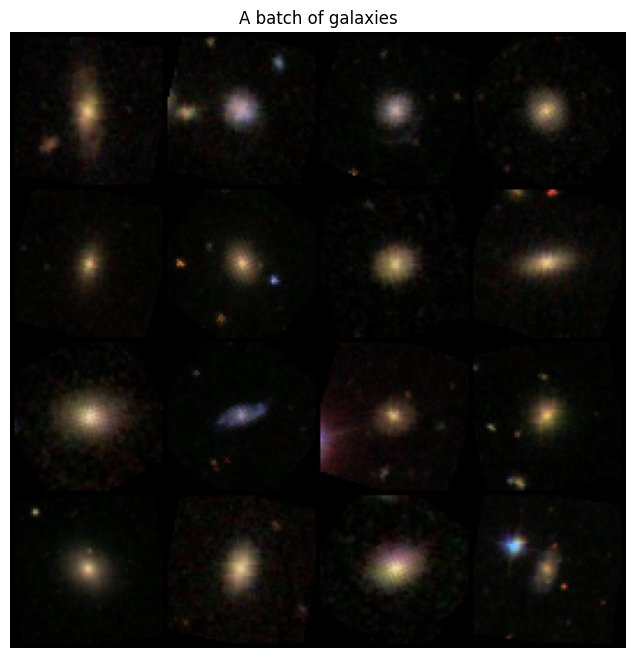

barred_spiral
spiral
spiral
spiral
elliptical
elliptical
elliptical
elliptical
elliptical
spiral
barred_spiral
elliptical
elliptical
elliptical
elliptical
barred_spiral


In [11]:
# TODO: un-normalise, make_grid(images[:16], nrow=4), permute, imshow, axis off.
#       Bonus: print [dataset.classes[i] for i in labels[:16]].
images_show = images * 0.5 + 0.5

grid = torchvision.utils.make_grid(images_show[:16], nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))   # (C,H,W) -> (H,W,C) for matplotlib
plt.axis("off")
plt.title("A batch of galaxies")
plt.show()
for i in labels[:16]:
  print(train_ds.classes[i])

## Stretch Goals *(optional)*

See [`09-project-task.md`](../09-project-task.md) for full descriptions:

1. Make a reproducible train/val split with `random_split` (seed it!).
2. Compute the **real** per-channel mean/std of the training set and use those in `Normalize`.
3. Plot several examples of each class side by side; guess which two will confuse a model.
4. Add `RandomHorizontalFlip` + `RandomRotation(180)` to a *train-only* transform and watch a galaxy flip/rotate.

In [12]:
# TODO (optional): one or more stretch goals.
n_val = int(0.15 * len(train_ds))
n_train = len(train_ds) - n_val
train_subset, val_subset = random_split(
    train_ds, [n_train, n_val],
    generator=torch.Generator().manual_seed(42),  # reproducible split
)
#4th goal already achieved

## Reflection *(write 2–3 sentences each)*

Answer the prompts from [`09-project-task.md`](../09-project-task.md):

1. Most confusing part of setup / the data pipeline, and how you resolved it.
2. Pick one galaxy class and describe what a CNN must detect to recognise it.
3. After viewing real batches: which two classes will be hardest to tell apart, and why?
4. Why so much effort on the data pipeline *before* any model?
* the raw data was flat and the folder layout was unknown so i printed the directory to check it and i took the help of AI to catgorise it and then split it into test and train
* to recognise a spiral galaxy the network classifies the galaxy by identifying a distinct two-component structure: a dense central bulge surrounded by a flat, extended exponential disk.
* elliptical and Lenticular galaxies prove the hardest to separate because both present as smooth, featureless, amber-colored profiles lacking any distinct arms or dust lanes
* getting the data structured and loaded correctly is very important to have a good model quality.